In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout

C:\Users\mirza\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

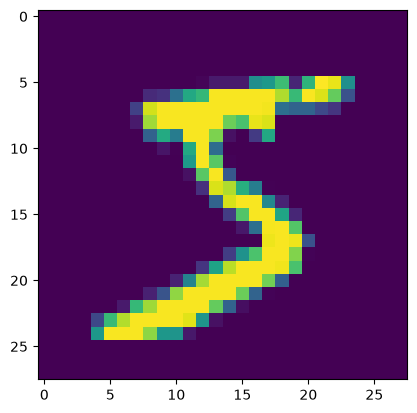

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [5]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [6]:
X_train, X_test = X_train/255.0 , X_test/255.0

In [7]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [8]:
model = Sequential()

In [9]:
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))

C:\Users\mirza\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [12]:
## Early Stoping
early_stoping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [13]:
history = model.fit(X_train,y_train,validation_split=0.2,batch_size=10,epochs=1000,callbacks=early_stoping )

Epoch 1/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.8902 - loss: 0.3635 - val_accuracy: 0.9566 - val_loss: 0.1463
Epoch 2/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9444 - loss: 0.1897 - val_accuracy: 0.9683 - val_loss: 0.1111
Epoch 3/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9550 - loss: 0.1523 - val_accuracy: 0.9701 - val_loss: 0.1028
Epoch 4/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9621 - loss: 0.1286 - val_accuracy: 0.9728 - val_loss: 0.0951
Epoch 5/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9651 - loss: 0.1146 - val_accuracy: 0.9734 - val_loss: 0.0940
Epoch 6/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9688 - loss: 0.1047 - val_accuracy: 0.9714 - val_loss: 0.1046
Epoch 7/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9705 - loss: 0.1005 - val_accuracy: 0.9735 - val_loss: 0.0979
Epoch 8/1000
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9728 -

In [14]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


In [15]:
y_prob

array([[7.5142224e-20, 1.9771955e-14, 7.5718365e-10, ..., 1.0000000e+00,
        7.7175117e-14, 3.9091672e-09],
       [1.4141088e-17, 5.3405131e-11, 1.0000000e+00, ..., 4.1710064e-12,
        1.8934333e-11, 1.6065784e-21],
       [1.4773195e-10, 9.9987257e-01, 9.8781561e-07, ..., 1.7768186e-06,
        8.6067557e-05, 1.1634882e-08],
       ...,
       [1.4656388e-20, 1.2396115e-15, 1.1845338e-16, ..., 3.2914483e-12,
        3.2550246e-13, 5.9994781e-10],
       [5.5095182e-17, 6.3645172e-23, 4.0889468e-22, ..., 4.7329656e-19,
        1.9720856e-09, 4.1362923e-15],
       [2.1005013e-15, 3.0795511e-20, 7.0263795e-10, ..., 2.2658385e-20,
        2.4861412e-16, 1.7313527e-18]], shape=(10000, 10), dtype=float32)

In [16]:
y_pred = y_prob.argmax(axis=1)

In [17]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.974

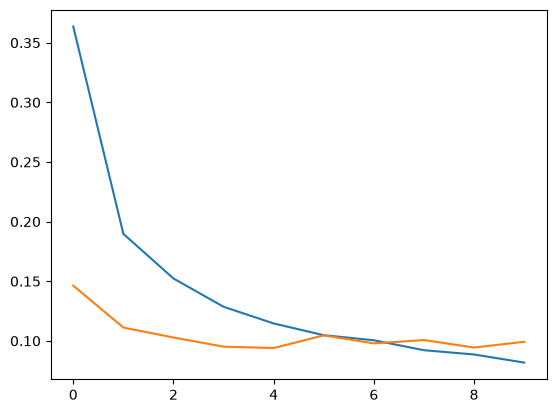

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

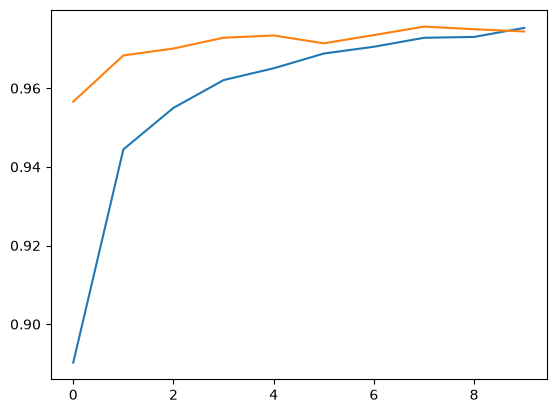

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

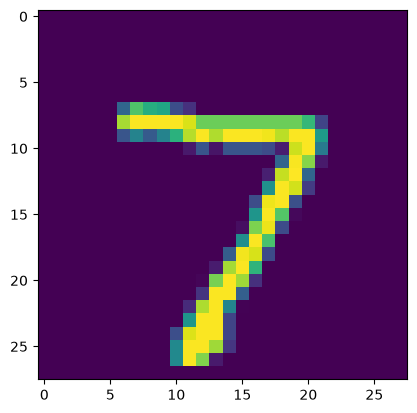

In [20]:
plt.imshow(X_test[0])

In [21]:
model.predict(X_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([7])

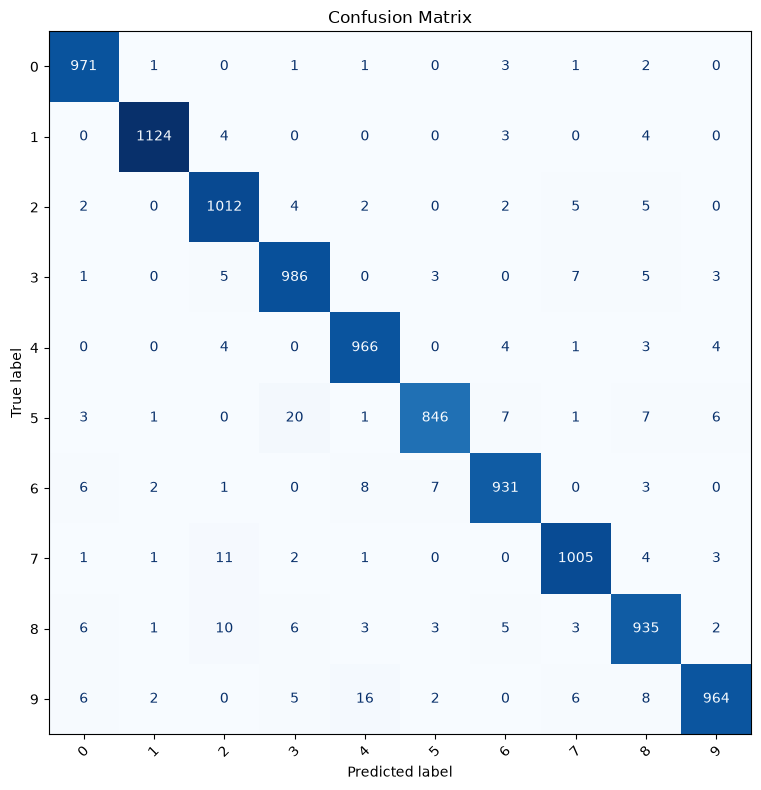

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_names = [str(i) for i in range(10)]
cm = confusion_matrix(y_test, y_pred, labels=range(10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score, 
                             matthews_corrcoef)

# 1. Generate the predictions (This fixes the NameError!)
y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)

# 2. One-hot encode the true labels for the PR-AUC score
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)

# 3. Calculate all metrics 
# (Precision, Recall, and F1 need the 'average' parameter for multi-class)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro') 
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
pr_auc = average_precision_score(y_test_binarized, y_pred_proba)
mcc = matthews_corrcoef(y_test, y_pred)

# 4. Print the results
print(f"Accuracy:             {accuracy:.4f}")
print(f"Precision (Macro):    {precision:.4f}")
print(f"Recall (Macro):       {recall:.4f}")
print(f"F1 Score (Macro):     {f1:.4f}")
print(f"ROC-AUC (OvR):        {roc_auc:.4f}")
print(f"PR-AUC (avg. prec.):  {pr_auc:.4f}")
print(f"MCC:                  {mcc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step
Accuracy:             0.9740
Precision (Macro):    0.9739
Recall (Macro):       0.9735
F1 Score (Macro):     0.9736
ROC-AUC (OvR):        0.9994
PR-AUC (avg. prec.):  0.9960
MCC:                  0.9711
